In [1]:
from google.colab import drive
drive.mount("/content/drive")
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import CIFAR10

In [3]:
#Datasets & DataLoaders
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset=CIFAR10(root="data",train=True,download=True,transform=transform)
testset=CIFAR10(root="data",train=False,download=True,transform=transform)

In [4]:
trainLoader=DataLoader(trainset,batch_size=64,shuffle=True)
testLoader=DataLoader(testset,batch_size=64)

### Build the CNN

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.convo_layers=nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2), # kernel size = 2, stride = 2

            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.fc_layers=nn.Sequential(
            nn.Linear(4*4*128,256),
            nn.ReLU(),

            nn.Linear(256,10)
        )

    def forward(self,x):
        x=self.convo_layers(x)
        x=x.view(x.size(0),-1) # flattening
        x=self.fc_layers(x)

        return x

In [6]:
model=CNN()

In [7]:
criterion=nn.CrossEntropyLoss()
optimizers=optim.Adam(model.parameters())

### Training the CNN

In [8]:
epochs=10
train_losses=[]
val_losses=[]
best_val_loss=float("inf")
for epoch in range(epochs):
    model.train()
    running_loss=0.0

    for image,label in trainLoader:
        optimizers.zero_grad()

        output=model.forward(image) #FP
        loss=criterion(output,label) # loss fnx
        loss.backward() #BP
        optimizers.step() # update params

        running_loss+=loss.item()
    epoch_training_loss=running_loss/len(trainLoader)
    train_losses.append(epoch_training_loss)

    # Validation
    model.eval()
    running_val_loss=0.0
    with torch.no_grad():
        for image,label in testLoader:
            output=model.forward(image) #FP
            loss=criterion(output,label) # loss fnx
            running_val_loss+=loss.item()

    epoch_val_loss=running_val_loss/len(testLoader)
    val_losses.append(epoch_val_loss)

    print(f"epoch{epoch+1}/{epochs} => training_loss={epoch_training_loss} & validation_loss={epoch_val_loss}")

epoch1/10 => training_loss=1.36698287961733 & validation_loss=1.0654989237997943
epoch2/10 => training_loss=0.935070547987433 & validation_loss=0.8555129910730253
epoch3/10 => training_loss=0.7446684777508001 & validation_loss=0.7838258864773306
epoch4/10 => training_loss=0.6093158087004786 & validation_loss=0.7637532269878752
epoch5/10 => training_loss=0.5005883903950071 & validation_loss=0.7485808627620624
epoch6/10 => training_loss=0.3994042149285221 & validation_loss=0.7755879704739638
epoch7/10 => training_loss=0.3066289623737183 & validation_loss=0.8679974341088799
epoch8/10 => training_loss=0.23871790897815734 & validation_loss=0.9279392764067195
epoch9/10 => training_loss=0.18209121725462435 & validation_loss=1.0347508860241836
epoch10/10 => training_loss=0.14462586696428792 & validation_loss=1.1239361888284136


Text(0, 0.5, 'Losses')

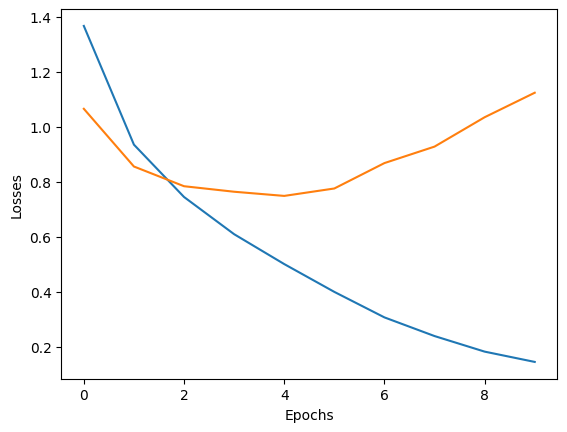

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
loss_df = pd.DataFrame({"Training_Loss": train_losses, "Validation_Loss": val_losses})
plt.plot(loss_df["Training_Loss"], label="Training Loss")
plt.plot(loss_df["Validation_Loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")

In [10]:
# Evaluate our CNN
correct_labels=0
total_labels=0

model.eval()

with torch.no_grad():
    for images,labels in testLoader:
        outputs=model.forward(images)
        _,predicted=torch.max(outputs,1)

        correct_labels+=(predicted==labels).sum().item()
        total_labels+=labels.size(0)

print(f"accuracy score:{correct_labels/total_labels*100}")

accuracy score:74.89
